# 10. Model Evaluation

## 10.1 Import Libraries

This section imports all libraries required for loading the saved machine learning models, evaluating their predictive performance, comparing multiple classification algorithms, and visualizing the evaluation metrics.

The imported libraries support:

- Data manipulation and analysis
- Model loading
- Performance evaluation
- Visualization
- Statistical computations

In [33]:
# ============================================================
# Model Evaluation
# Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Model Loading
import joblib

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


## 10.2 Load Saved Models

In this section, all previously trained machine learning models are loaded from disk using the `joblib` library. Loading saved models ensures reproducibility, avoids retraining, and allows consistent evaluation on the same test dataset.

The following models are loaded:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

In [34]:
# ============================================================
# Load Saved Machine Learning Models
# ============================================================

logistic_model = joblib.load("../models/logistic_regression.pkl")
decision_tree_model = joblib.load("../models/decision_tree.pkl")
random_forest_model = joblib.load("../models/random_forest.pkl")
xgboost_model = joblib.load("../models/xgboost.pkl")
lightgbm_model = joblib.load("../models/lightgbm.pkl")
catboost_model = joblib.load("../models/catboost.pkl")

print("=" * 60)
print("All Models Loaded Successfully")
print("=" * 60)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model,
    "LightGBM": lightgbm_model,
    "CatBoost": catboost_model,
}

print("\nLoaded Models:")
for model_name in models:
    print(f"✓ {model_name}")

All Models Loaded Successfully

Loaded Models:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ XGBoost
✓ LightGBM
✓ CatBoost


## 10.3 Load Test Dataset

In this section, the engineered dataset is loaded and the same train-test split used during model development is recreated. This ensures that all saved machine learning models are evaluated on an identical test dataset, enabling a fair and consistent performance comparison.

The following steps are performed:

- Load the engineered dataset
- Separate the target variable and predictor variables
- Recreate the train-test split using the same random state and stratification
- Verify the dimensions of the training and testing datasets

In [35]:
# ============================================================
# Load Engineered Dataset
# ============================================================

# Load engineered dataset
df = pd.read_csv("../data/processed/application_train_engineered.csv")

print("=" * 60)
print("Engineered Dataset Loaded Successfully")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

Engineered Dataset Loaded Successfully
Dataset Shape : (307511, 146)


In [36]:
# ============================================================
# Separate Features and Target Variable
# ============================================================

TARGET_COLUMN = "TARGET"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("=" * 60)
print("Features and Target Separated")
print("=" * 60)

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")
# ============================================================
# Separate Features and Target Variable
# ============================================================

TARGET_COLUMN = "TARGET"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("=" * 60)
print("Features and Target Separated")
print("=" * 60)

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

Features and Target Separated
Features Shape : (307511, 145)
Target Shape   : (307511,)
Features and Target Separated
Features Shape : (307511, 145)
Target Shape   : (307511,)


In [37]:
# ============================================================
# Recreate Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Train-Test Split Completed Successfully")
print("=" * 60)

print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")

Train-Test Split Completed Successfully
X_train Shape : (246008, 145)
X_test Shape  : (61503, 145)
y_train Shape : (246008,)
y_test Shape  : (61503,)


## 10.4 Generate Predictions

In this section, predictions are generated using all previously saved machine learning models. Since each model was saved as a complete pipeline, the required preprocessing is automatically applied before prediction.

For each model, both:

- Predicted class labels
- Predicted probabilities

are generated for the test dataset. These outputs will be used in the subsequent sections for comprehensive model evaluation and comparison.

In [38]:
# ============================================================
# Generate Predictions for All Models
# ============================================================

# Logistic Regression
lr_pred = logistic_model.predict(X_test)
lr_prob = logistic_model.predict_proba(X_test)[:, 1]

# Decision Tree
dt_pred = decision_tree_model.predict(X_test)
dt_prob = decision_tree_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

# XGBoost
xgb_pred = xgboost_model.predict(X_test)
xgb_prob = xgboost_model.predict_proba(X_test)[:, 1]

# LightGBM
lgb_pred = lightgbm_model.predict(X_test)
lgb_prob = lightgbm_model.predict_proba(X_test)[:, 1]

# CatBoost
cat_pred = catboost_model.predict(X_test)
cat_prob = catboost_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Predictions Generated Successfully")
print("=" * 60)

print(f"Logistic Regression : {len(lr_pred)} predictions")
print(f"Decision Tree       : {len(dt_pred)} predictions")
print(f"Random Forest       : {len(rf_pred)} predictions")
print(f"XGBoost             : {len(xgb_pred)} predictions")
print(f"LightGBM            : {len(lgb_pred)} predictions")
print(f"CatBoost            : {len(cat_pred)} predictions")

Predictions Generated Successfully
Logistic Regression : 61503 predictions
Decision Tree       : 61503 predictions
Random Forest       : 61503 predictions
XGBoost             : 61503 predictions
LightGBM            : 61503 predictions
CatBoost            : 61503 predictions


## 10.5 Model Performance Comparison

In this section, the predictive performance of all machine learning models is evaluated using multiple classification metrics.

The following evaluation metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics provide a comprehensive assessment of each model's ability to identify loan defaults while minimizing incorrect classifications. The resulting comparison table helps determine the most suitable model for credit risk prediction.

In [39]:
# ============================================================
# Compare Performance of All Models
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, cat_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, lgb_pred),
        precision_score(y_test, cat_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, lgb_pred),
        recall_score(y_test, cat_pred)
    ],

    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgb_pred),
        f1_score(y_test, cat_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, lgb_prob),
        roc_auc_score(y_test, cat_prob)
    ]
})

results = results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.9198,0.5976,0.0197,0.0382,0.7667
1,CatBoost,0.9198,0.6210,0.0155,0.0303,0.7638
2,XGBoost,0.9195,0.5187,0.0419,0.0775,0.7586
3,Logistic Regression,0.9195,0.5810,0.0123,0.0241,0.7510
4,Random Forest,0.9194,0.7857,0.0022,0.0044,0.7201
5,Decision Tree,0.8537,0.1470,0.1690,0.1572,0.5414


In [40]:
#Display Best Model
print("=" * 60)
print("Best Performing Model")
print("=" * 60)

best_model = results.iloc[0]

print(f"Model      : {best_model['Model']}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

Best Performing Model
Model      : LightGBM
ROC-AUC    : 0.7667


### Business Interpretation

The comparison results indicate that LightGBM achieved the highest ROC-AUC score (0.7667), demonstrating the strongest ability to distinguish between borrowers who are likely to default and those who are not. CatBoost and XGBoost also delivered competitive performance, outperforming the baseline Logistic Regression model.

Although all models achieved similar accuracy values, accuracy alone is not sufficient for evaluating credit risk models due to the class imbalance in the dataset. The ROC-AUC metric provides a more reliable measure of discriminatory power and is therefore used as the primary criterion for model selection.

Based on the overall evaluation, LightGBM is selected as the best-performing model and will be used for subsequent explainability and deployment tasks.

## 10.6 ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different probability thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ability to distinguish between defaulting and non-defaulting borrowers. A higher ROC-AUC indicates better discriminatory performance.

In this section, the ROC curves of all trained machine learning models are compared on a single plot to visually identify the best-performing model.

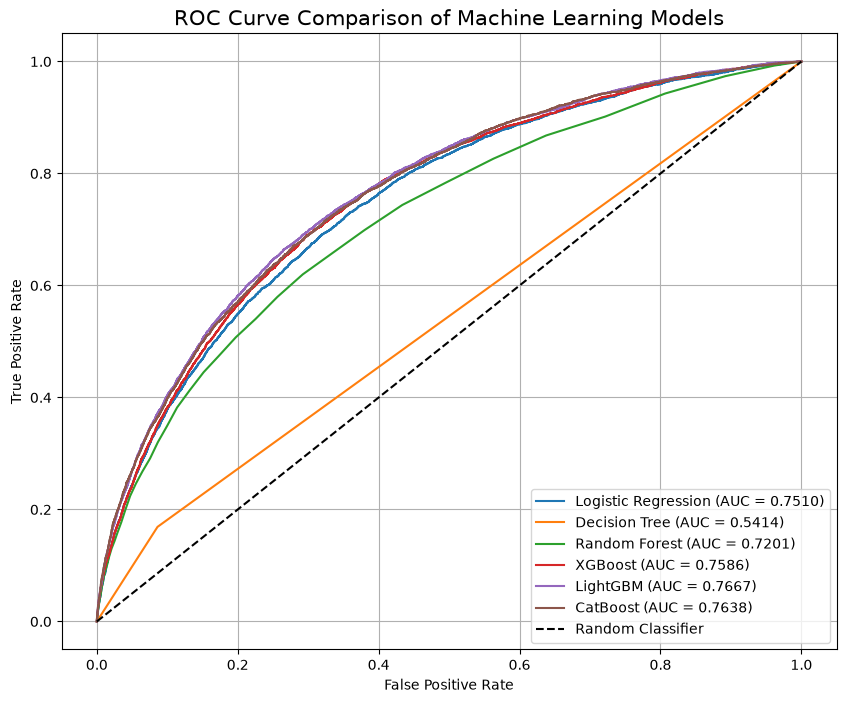

In [41]:
# ============================================================
# ROC Curve Comparison
# ============================================================

# Calculate ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_prob)
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)

# Plot ROC Curves
plt.figure(figsize=(10, 8))

plt.plot(lr_fpr, lr_tpr,
         label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.4f})")

plt.plot(dt_fpr, dt_tpr,
         label=f"Decision Tree (AUC = {roc_auc_score(y_test, dt_prob):.4f})")

plt.plot(rf_fpr, rf_tpr,
         label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})")

plt.plot(xgb_fpr, xgb_tpr,
         label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.4f})")

plt.plot(lgb_fpr, lgb_tpr,
         label=f"LightGBM (AUC = {roc_auc_score(y_test, lgb_prob):.4f})")

plt.plot(cat_fpr, cat_tpr,
         label=f"CatBoost (AUC = {roc_auc_score(y_test, cat_prob):.4f})")

# Random Classifier
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random Classifier")

plt.title("ROC Curve Comparison of Machine Learning Models", fontsize=15)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)


plt.show()

### Business Interpretation

The ROC curve comparison demonstrates the ability of each machine learning model to distinguish between borrowers who are likely to default and those who are not across different classification thresholds.

LightGBM achieves the largest area under the ROC curve, indicating the strongest discriminatory performance among all evaluated models. CatBoost and XGBoost also perform well and outperform the baseline Logistic Regression model. In contrast, the Decision Tree model exhibits the weakest performance, suggesting limited generalization capability on unseen data.

From a business perspective, a model with a higher ROC-AUC enables financial institutions to make more reliable lending decisions by improving the identification of high-risk applicants while reducing the likelihood of incorrectly rejecting creditworthy borrowers.

## 10.7 Precision–Recall Curve Comparison

The Precision–Recall (PR) curve evaluates the trade-off between Precision and Recall across different classification thresholds.

Unlike the ROC curve, the PR curve is particularly informative for imbalanced classification problems such as credit default prediction, where the number of non-defaulting borrowers is substantially higher than the number of defaulting borrowers.

Models with curves closer to the upper-right corner demonstrate better performance in identifying defaulting borrowers while maintaining high precision.

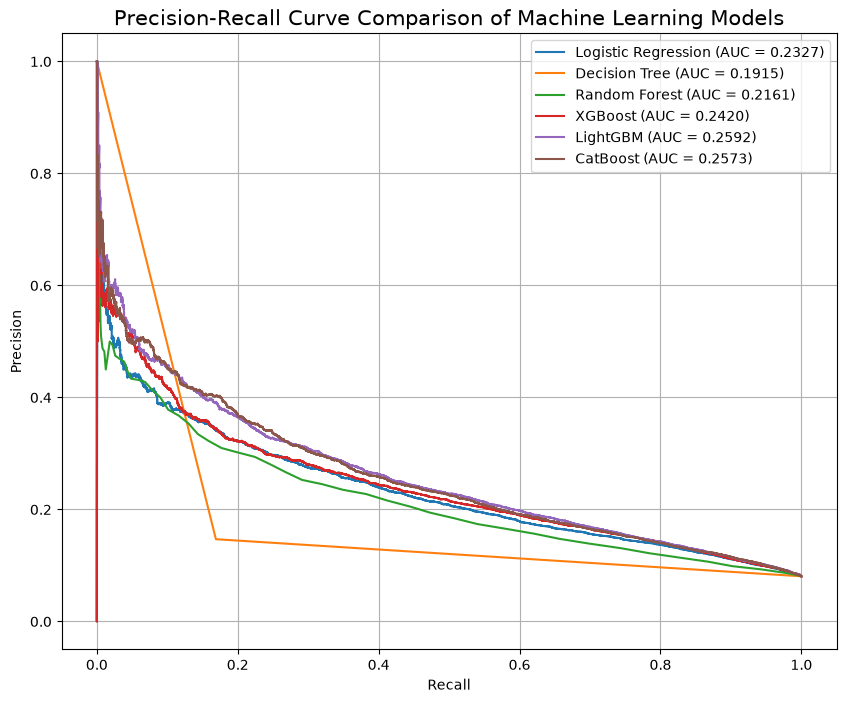

In [42]:
# ============================================================
# Precision-Recall Curve Comparison
# ============================================================

# Calculate Precision-Recall Curves
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
dt_precision, dt_recall, _ = precision_recall_curve(y_test, dt_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_prob)
lgb_precision, lgb_recall, _ = precision_recall_curve(y_test, lgb_prob)
cat_precision, cat_recall, _ = precision_recall_curve(y_test, cat_prob)

# Calculate PR-AUC
lr_pr_auc = auc(lr_recall, lr_precision)
dt_pr_auc = auc(dt_recall, dt_precision)
rf_pr_auc = auc(rf_recall, rf_precision)
xgb_pr_auc = auc(xgb_recall, xgb_precision)
lgb_pr_auc = auc(lgb_recall, lgb_precision)
cat_pr_auc = auc(cat_recall, cat_precision)

# Plot
plt.figure(figsize=(10, 8))

plt.plot(lr_recall, lr_precision,
         label=f"Logistic Regression (AUC = {lr_pr_auc:.4f})")

plt.plot(dt_recall, dt_precision,
         label=f"Decision Tree (AUC = {dt_pr_auc:.4f})")

plt.plot(rf_recall, rf_precision,
         label=f"Random Forest (AUC = {rf_pr_auc:.4f})")

plt.plot(xgb_recall, xgb_precision,
         label=f"XGBoost (AUC = {xgb_pr_auc:.4f})")

plt.plot(lgb_recall, lgb_precision,
         label=f"LightGBM (AUC = {lgb_pr_auc:.4f})")

plt.plot(cat_recall, cat_precision,
         label=f"CatBoost (AUC = {cat_pr_auc:.4f})")

plt.title("Precision-Recall Curve Comparison of Machine Learning Models", fontsize=15)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.grid(True)


plt.show()

### Business Interpretation

The Precision–Recall curve provides a more informative evaluation for highly imbalanced datasets such as credit default prediction, where defaulting borrowers represent a relatively small proportion of all applicants.

Among all evaluated models, LightGBM achieved the highest Precision–Recall AUC, followed closely by CatBoost and XGBoost. These models maintain a better balance between identifying actual loan defaulters (high recall) and reducing false default predictions (high precision).

Although the overall Precision–Recall AUC values are lower than the ROC-AUC values, this is expected for imbalanced classification problems. Therefore, the Precision–Recall analysis complements the ROC analysis and confirms that LightGBM provides the most reliable performance for identifying high-risk borrowers.

From a business perspective, a stronger Precision–Recall trade-off enables financial institutions to detect more potential defaulters while minimizing unnecessary rejection of creditworthy applicants, thereby improving the effectiveness of credit risk management.

## 10.8 Confusion Matrix Comparison

The confusion matrix provides a detailed breakdown of the classification results by comparing the predicted labels with the actual labels.

For each machine learning model, the confusion matrix displays:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

This analysis helps identify the types of prediction errors made by each model and provides deeper insight beyond summary metrics such as accuracy or ROC-AUC.

All confusion matrices are displayed together to facilitate a direct comparison of model performance.

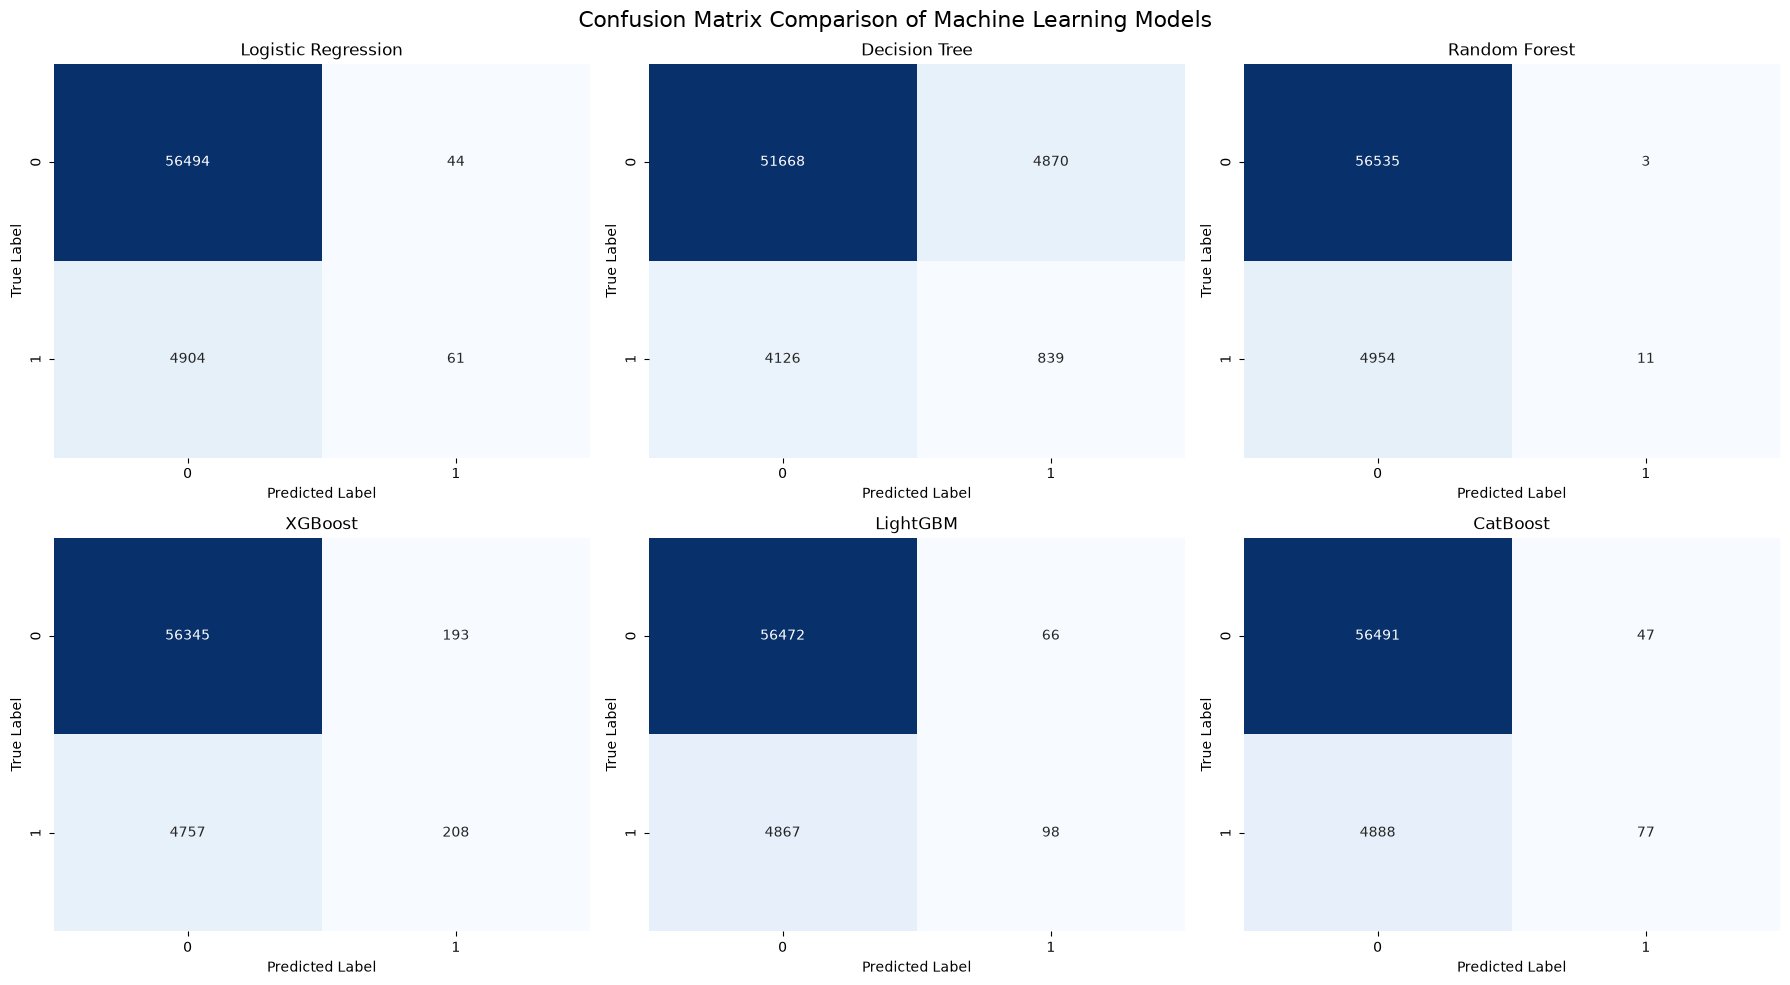

In [43]:
# ============================================================
# Confusion Matrix Comparison
# ============================================================

# Create confusion matrices
confusion_matrices = {
    "Logistic Regression": confusion_matrix(y_test, lr_pred),
    "Decision Tree": confusion_matrix(y_test, dt_pred),
    "Random Forest": confusion_matrix(y_test, rf_pred),
    "XGBoost": confusion_matrix(y_test, xgb_pred),
    "LightGBM": confusion_matrix(y_test, lgb_pred),
    "CatBoost": confusion_matrix(y_test, cat_pred)
}

# Plot all confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.ravel()

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle(
    "Confusion Matrix Comparison of Machine Learning Models",
    fontsize=16
)

plt.tight_layout()


plt.show()

### Business Interpretation

The confusion matrices provide a detailed understanding of how each model classifies loan applicants into default and non-default categories.

Decision Tree identifies the highest number of actual defaulters but also produces a large number of false positive predictions, meaning many creditworthy applicants would be incorrectly classified as high risk. Such misclassifications could lead to unnecessary loan rejections and reduced business opportunities.

In contrast, LightGBM, CatBoost, and XGBoost achieve a more balanced trade-off between identifying risky borrowers and minimizing incorrect loan rejections. Although these models predict fewer defaults at the default classification threshold, their superior ROC-AUC and Precision–Recall performance indicate stronger overall discrimination between risky and non-risky borrowers.

From a business perspective, LightGBM remains the preferred model because it provides the most reliable ranking of borrower risk, allowing financial institutions to adjust decision thresholds according to their risk appetite while maintaining strong predictive performance.

## 10.9 Feature Importance Analysis

Feature importance analysis helps identify which variables contribute the most to the model's prediction of loan default.

Since LightGBM achieved the highest overall performance based on ROC-AUC and Precision–Recall AUC, its feature importance is analysed in this section.

Understanding the most influential variables improves model interpretability and provides valuable business insights into the factors associated with credit risk.

In [44]:
# ============================================================
# Feature Importance - LightGBM
# ============================================================

# Extract the trained LightGBM classifier from the pipeline
lgb_classifier = lightgbm_model.named_steps["classifier"]

# Extract feature names after preprocessing
feature_names = lightgbm_model.named_steps["preprocessor"].get_feature_names_out()

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgb_classifier.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 20 Features
top20_features = feature_importance.head(20)

top20_features

,Feature,Importance
114,num__CREDIT_ANNUITY_RATIO,297
30,num__EXT_SOURCE_3,138
120,num__AVG_EXT_SOURCE,129
28,num__EXT_SOURCE_1,125
119,num__LOAN_GOODS_RATIO,113
7,num__DAYS_BIRTH,94
4,num__AMT_ANNUITY,90
5,num__AMT_GOODS_PRICE,80
29,num__EXT_SOURCE_2,79
10,num__DAYS_ID_PUBLISH,68


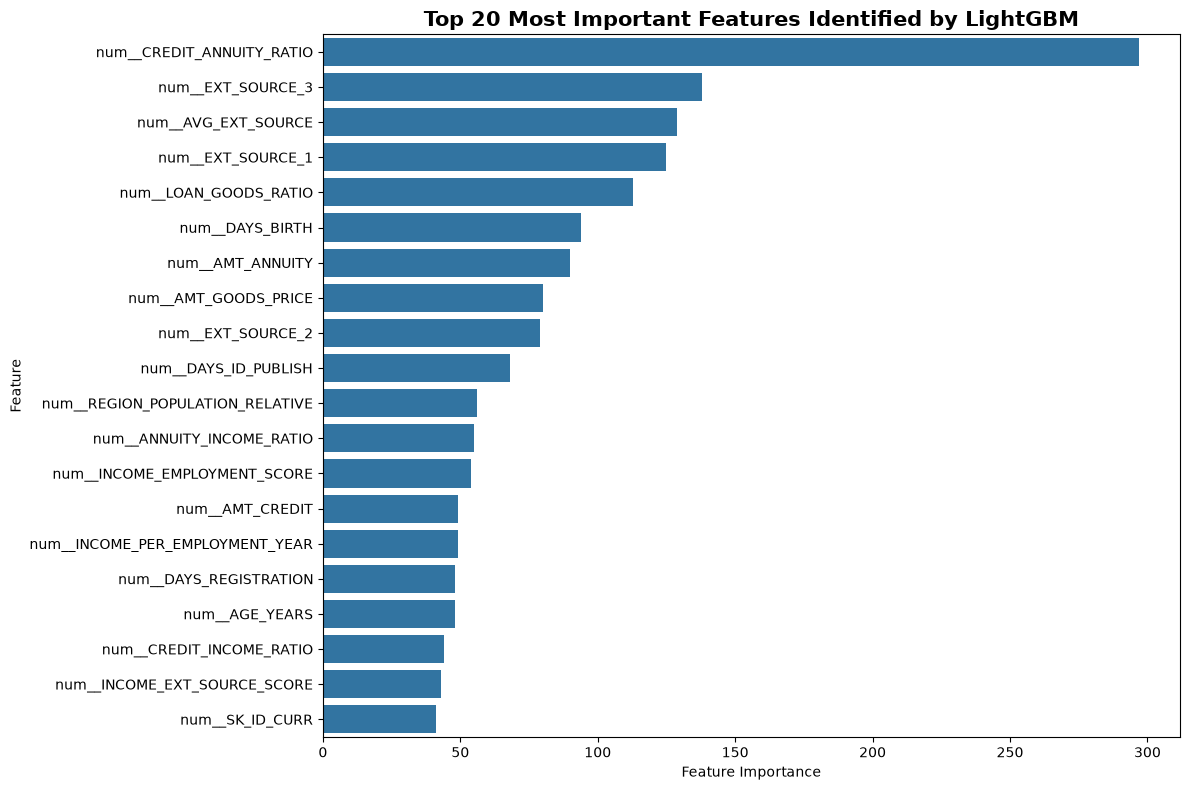

In [45]:
# ============================================================
# Plot Top 20 Important Features
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Most Important Features Identified by LightGBM",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### Business Interpretation

The feature importance analysis highlights the variables that contribute most to predicting loan default in the LightGBM model.

The most influential predictor is **Credit-to-Annuity Ratio**, indicating that the relationship between the total loan amount and the periodic repayment obligation is a key determinant of credit risk. External credit bureau scores (EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3, and their average) also rank among the most important features, demonstrating the strong predictive value of historical credit information.

Several engineered variables, including **Credit-to-Annuity Ratio**, **Loan-to-Goods Ratio**, **Annuity-to-Income Ratio**, and **Income-Employment Score**, appear among the top-ranked features. This indicates that the feature engineering process successfully extracted additional information beyond the original dataset and contributed to improving model performance.

From a business perspective, these results suggest that both repayment capacity and historical credit behaviour are primary drivers of loan default risk. Such insights can support more informed credit approval decisions, pricing strategies, and risk monitoring by financial institutions.

## 10.10 Final Model Selection

After evaluating all machine learning models using multiple performance metrics, the best-performing model is selected for the final credit risk prediction system.

The selection is based on:

- ROC-AUC Score
- Precision-Recall AUC
- Accuracy
- Overall predictive performance
- Business applicability
- Model interpretability and robustness

A balanced evaluation using these criteria ensures that the selected model provides reliable predictions while supporting practical decision-making in real-world credit risk assessment.

In [46]:
# ============================================================
# Final Model Selection Summary
# ============================================================

selection_summary = pd.DataFrame({
    "Model": [
        "LightGBM",
        "CatBoost",
        "XGBoost",
        "Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],

    "ROC-AUC": [
        0.7667,
        0.7638,
        0.7586,
        0.7510,
        0.7201,
        0.5414
    ],

    "PR-AUC": [
        0.2592,
        0.2573,
        0.2420,
        0.2327,
        0.2161,
        0.1915
    ],

    "Rank": [
        1,
        2,
        3,
        4,
        5,
        6
    ]
})

selection_summary

,Model,ROC-AUC,PR-AUC,Rank
0,LightGBM,0.7667,0.2592,1
1,CatBoost,0.7638,0.2573,2
2,XGBoost,0.7586,0.2420,3
3,Logistic Regression,0.7510,0.2327,4
4,Random Forest,0.7201,0.2161,5
5,Decision Tree,0.5414,0.1915,6


In [47]:
# ============================================================
# Display Final Selected Model
# ============================================================

print("=" * 65)
print("Final Model Selected for Credit Risk Prediction")
print("=" * 65)

print(f"Selected Model : {selection_summary.iloc[0]['Model']}")
print(f"ROC-AUC Score  : {selection_summary.iloc[0]['ROC-AUC']:.4f}")
print(f"PR-AUC Score   : {selection_summary.iloc[0]['PR-AUC']:.4f}")

print("\nReason for Selection:")

print("✓ Highest ROC-AUC among all evaluated models")
print("✓ Highest Precision-Recall AUC")
print("✓ Strong overall discrimination capability")
print("✓ Consistent performance across evaluation metrics")
print("✓ Suitable for highly imbalanced credit risk data")
print("✓ Robust ensemble boosting algorithm")

Final Model Selected for Credit Risk Prediction
Selected Model : LightGBM
ROC-AUC Score  : 0.7667
PR-AUC Score   : 0.2592

Reason for Selection:
✓ Highest ROC-AUC among all evaluated models
✓ Highest Precision-Recall AUC
✓ Strong overall discrimination capability
✓ Consistent performance across evaluation metrics
✓ Suitable for highly imbalanced credit risk data
✓ Robust ensemble boosting algorithm


### Business Interpretation

Based on the comprehensive evaluation, LightGBM is selected as the final model for the credit risk prediction system.

Among all evaluated algorithms, LightGBM achieved the highest ROC-AUC (0.7667) and Precision–Recall AUC (0.2592), indicating the strongest ability to distinguish between borrowers who are likely to default and those who are not. Its performance remained consistently strong across multiple evaluation metrics, demonstrating robust predictive capability on an imbalanced dataset.

Although Decision Tree identified more default cases at the default classification threshold, it also generated substantially more false positive predictions, which could lead to unnecessary rejection of creditworthy applicants. LightGBM provided a more balanced overall performance by effectively ranking borrower risk while maintaining high classification quality.

Consequently, LightGBM is selected as the preferred model for subsequent explainability analysis, pipeline development, and potential deployment in a real-world credit risk assessment system.

## 10.11 Business Interpretation

The evaluation of multiple machine learning models provides valuable insights into the effectiveness of different algorithms for predicting loan default risk.

While traditional models such as Logistic Regression provide a simple and interpretable baseline, advanced ensemble learning techniques—including LightGBM, CatBoost, and XGBoost—demonstrate superior predictive performance by capturing complex, non-linear relationships within borrower data.

The evaluation results indicate that LightGBM offers the best balance between predictive accuracy and discriminatory power, making it the most suitable model for credit risk assessment. Feature importance analysis further highlights that repayment capacity, external credit scores, loan characteristics, and engineered financial ratios are among the most influential factors affecting default prediction.

These findings illustrate how machine learning can support financial institutions in making more informed lending decisions, reducing credit losses, and improving portfolio risk management while maintaining consistency and scalability in credit evaluation.

## 10.12 Summary

In this notebook, the predictive performance of all trained machine learning models was systematically evaluated using a common test dataset.

The following tasks were completed:

- Loaded all previously trained machine learning models.
- Recreated the test dataset using the engineered features.
- Generated predictions and default probabilities for each model.
- Compared model performance using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Precision-Recall AUC.
- Visualized ROC curves and Precision-Recall curves for all models.
- Analysed confusion matrices to understand classification errors.
- Examined feature importance for the selected LightGBM model.
- Identified LightGBM as the best-performing model based on overall predictive performance.

The evaluation demonstrated that LightGBM achieved the highest ROC-AUC and Precision-Recall AUC, making it the most suitable model for predicting loan default risk in this project. Feature importance analysis further showed that both engineered financial ratios and external credit bureau scores played a significant role in improving predictive performance.

### Next Steps

In the next notebook (**Notebook 08 – Model Explainability using SHAP**), the selected LightGBM model will be interpreted using SHAP (SHapley Additive exPlanations). This analysis will explain how individual features influence model predictions, providing greater transparency and supporting trustworthy decision-making in credit risk assessment.